# Model P- Random Forest - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate,StratifiedKFold, GridSearchCV
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

rfc =  RandomForestClassifier(random_state=RANDOM_STATE)

xtrain_P = pd.read_csv("xtrain_P.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=rfc,X=xtrain_P,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,1.864661,0.031883,0.727020,1.0
1,1.899236,0.034068,0.730629,1.0
2,1.937464,0.032135,0.708134,1.0
3,1.880505,0.032209,0.727307,1.0
4,1.881483,0.033115,0.716523,1.0


In [9]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.7219225818482754


Le Random Forest avec ses paramètres par défaut obtient un F1-macro moyen d’environ 0,721 en validation croisée. Les scores de validation varient entre environ 0,708 et 0,730, ce qui montre des performances relativement stables entre les différents folds.

En revanche, le F1-macro d’entraînement atteint 1,00 sur les cinq folds. Le modèle parvient donc à classifier presque parfaitement les observations utilisées pour son entraînement, mais ses performances diminuent nettement sur les observations de validation.

L’écart important entre le score d’entraînement (1,00) et le score moyen de validation (0,721) indique un surapprentissage important.

Cette baseline servira de référence pour l’optimisation des hyperparamètres. Le tuning devra chercher à réduire la complexité du Random Forest afin de diminuer cet écart, tout en maintenant ou en améliorant son F1-macro de validation.

## 3. Hyperparameter Tuning

In [10]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

settings_grid_2 = {
    "max_depth":[5, 10, 15, 20],
    "min_samples_leaf":[2, 5, 10],
    "min_samples_split":[2, 5, 10],
    "max_features":["sqrt", 0.5],
}


grid_search = GridSearchCV(estimator=rfc,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search_2 = GridSearchCV(estimator=rfc,param_grid=settings_grid_2,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_P,
    ytrain,
)



,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [11]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5}
Best validation F1: 0.7220396091333037
Mean train F1: 0.8927020787665555
Std validation F1: 0.005967221669291928


Avec ses paramètres par défaut, le Random Forest obtient un F1-macro moyen d'environ 0,722 en validation croisée, tandis que son score d'entraînement atteint 1,00 sur tous les folds. Cet écart important met en évidence un surapprentissage marqué : le modèle s'adapte presque parfaitement aux données d'entraînement mais généralise moins bien sur les données de validation.

Après optimisation, les meilleurs hyperparamètres sont `max_depth=20`, `max_features="sqrt"` et `min_samples_leaf=2`. Le **F1-macro moyen de validation** atteint 0,722, soit une **amélioration très faible** par **rapport à la baseline**. En revanche, le **F1-macro d'entraînement augmente à environ 0,892**, réduisant légèrement l'écart entre entraînement et validation.

Le **tuning** permet donc de **réduire partiellement le surapprentissage,** **mais** celui-ci **reste important**. La **faible amélioration du F1** de validation suggère également que les performances du Random Forest sont relativement peu sensibles aux hyperparamètres testés pour cette sélection de variables.

## 4. Final Evaluation

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_P = pd.read_csv("xtest_P.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_P)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7502628811777077
Precision macro : 0.7175878572320943
Recall macro : 0.7255360336805139
F1 macro : 0.7187018012775849


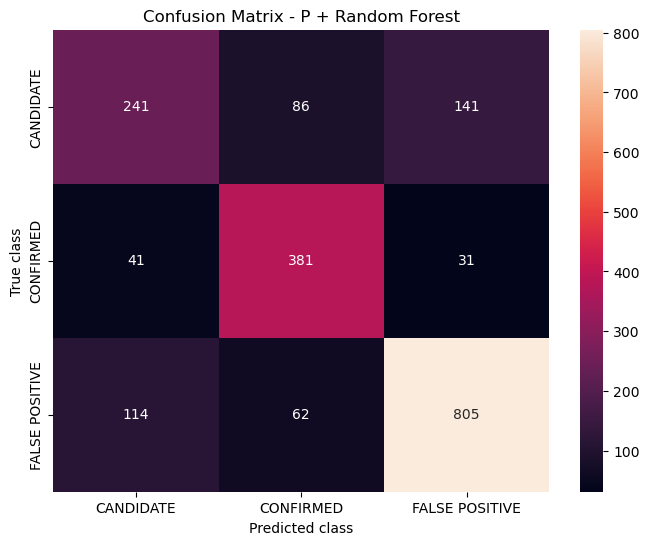

In [13]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - P + Random Forest")

plt.show()

La matrice de confusion montre que le Random Forest utilisant la sélection personnelle reconnaît correctement une grande partie des objets CONFIRMED et FALSE POSITIVE, tandis que la classe CANDIDATE reste la plus difficile à identifier.

Parmi les 468 CANDIDATE, 241 sont correctement classés, tandis que 86 sont prédits CONFIRMED et 141 sont prédits FALSE POSITIVE. Pour les 453 CONFIRMED, 381 sont correctement identifiés, avec relativement peu de confusions. Enfin, parmi les 981 FALSE POSITIVE, 805 sont correctement classés.

Le modèle est donc particulièrement performant pour les classes CONFIRMED et FALSE POSITIVE, mais rencontre davantage de difficultés avec les candidats, qui présentent davantage de chevauchement avec les deux autres classes.

## 5. Model Limits

La sélection personnelle permet au Random Forest d’obtenir de bonnes performances globales, mais la classe CANDIDATE reste nettement plus ambiguë que les deux autres. Cela suggère que les variables retenues manuellement capturent bien les signatures caractéristiques des objets confirmés et des faux positifs, mais qu’elles ne suffisent pas toujours à représenter les situations intermédiaires. Une limite possible de cette sélection est donc qu’elle repose sur des choix humains pertinents astrophysiquement, mais qui ne maximisent pas nécessairement la séparation statistique entre les trois classes.